# Project-out results: Loss Δ vs layer and vs k

Two plots:
1. **Layer (x) vs Loss Δ (y)** for a **specific k** — use when you have one result file per layer (e.g. runs with `--output-dir`). Title shows k.
2. **k (x) vs Loss Δ (y)** for a **specific layer** — use one result file that has multiple k (e.g. `--top-k "1,4,16,64,128"`). Title shows layer.

**Why does a single run in the terminal look different from the "layer vs delta" plot?**
- The **terminal** shows one run = **one layer** (one point). The **plot** shows many layers (one point per layer). So the terminal output is a single point on that plot; which layer you ran (`--layer_idx`) determines where it sits (e.g. early layers often have larger SVD deltas, later layers can be smaller).
- **Dataset and baseline** matter: e.g. `wiki_titles` (baseline ~7–8) vs `wikitext` (baseline ~2.5) change the scale of loss and deltas. Old plots may be from a different dataset or code version.
- To **match** the layer plot with current code: run for **many layers** (e.g. `for layer in 0 5 10 15 20 25; do ... --layer_idx $layer --output-dir results ...`) and plot; your single-run deltas will then appear as one layer’s point on the curve.

In [2]:
import sys
from pathlib import Path

# Find project root by walking up until we find 'src' directory
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments.router_interventions import (
    load_results,
    plot_delta_vs_layers,
    plot_delta_vs_k,
)

# Default folder for result JSONs (used by both plots)
RESULTS_DIR = ROOT / "results_scale10"

## 1. Plot: Loss Δ vs layer (for a specific k)

Load all result JSONs from a folder (one file per layer, each with `by_k`). Pick **k** for the title and x = layer index, y = loss delta.

In [8]:
# Override if your results are elsewhere
RESULTS_DIR = RESULTS_DIR  # or Path("/path/to/your/results")

# Which k to use for this plot (must exist in each file's by_k)
K_FOR_LAYER_PLOT = 256

# Load all project_out_*.json in the folder
result_files = sorted(RESULTS_DIR.glob("project_out_*.json"))
if not result_files:
    raise FileNotFoundError(f'No project_out_*.json in {RESULTS_DIR}. Run with --output-dir {RESULTS_DIR} for multiple layers.')

results_by_layer = [load_results(p) for p in result_files]
print(f"Loaded {len(results_by_layer)} result files. Layers: {[r.get('config', {}).get('layer_idx') for r in results_by_layer]}")

Loaded 32 result files. Layers: [0, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 1, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 2, 30, 31, 3, 4, 5, 6, 7, 8, 9]


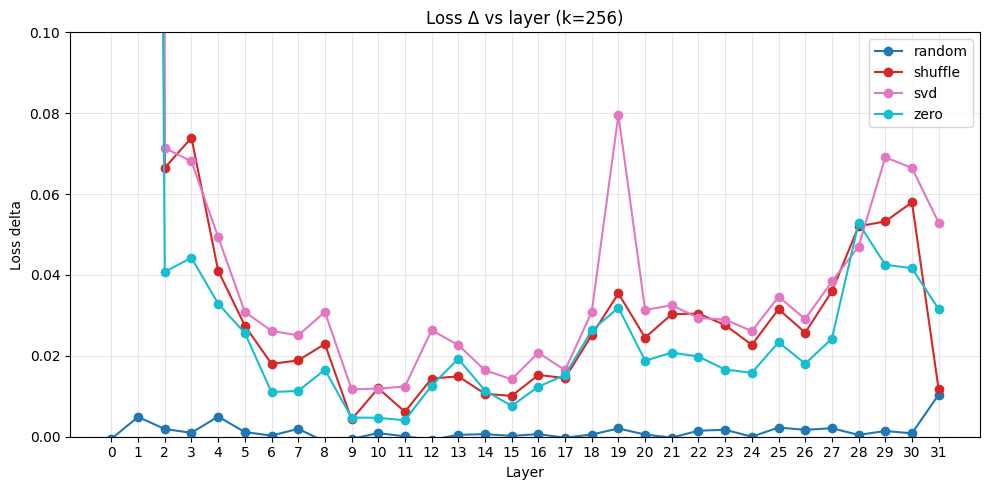

In [9]:
%matplotlib inline

fig = plot_delta_vs_layers(
    results_by_layer,
    K_FOR_LAYER_PLOT,
    title=f"Loss Δ vs layer (k={K_FOR_LAYER_PLOT})",
    ylim=(0, 0.1),  # REMOVED - was cutting off zero/shuffle variants at ~1.0
    # You can add it back if you want to zoom into svd/random only
)
fig.show()

## 2. Plot: Loss Δ vs k (for a specific layer or multiple layers)

Load result file(s) that have multiple k values. x = k, y = loss delta.

**Usage examples:**
- Single layer: `LAYERS_TO_PLOT = [0]` - plots only layer 0
- Multiple layers: `LAYERS_TO_PLOT = [0, 1, 2, 3]` - compares layers 0-3 on same chart
- All layers: `LAYERS_TO_PLOT = None` - plots all available layers together

This allows you to:
- Compare how different layers respond to the same k values
- Identify which layers are most/least sensitive to interventions
- Zoom into specific layers of interest

In [ ]:
# Choose which layer(s) to plot. Options:
# 1. Single layer: LAYERS_TO_PLOT = [0]  
# 2. Multiple layers: LAYERS_TO_PLOT = [0, 1, 2]
# 3. All available: LAYERS_TO_PLOT = None

LAYERS_TO_PLOT = [0,1,2,3,4,5]  # Set to None for all layers or specify [0, 1, 2, etc.]

# Load data for the selected layers
if LAYERS_TO_PLOT is None:
    # Load all available result files
    layer_results = {r.get("config", {}).get("layer_idx"): r 
                     for r in results_by_layer}
else:
    # Load specific layers
    layer_results = {}
    for layer_idx in LAYERS_TO_PLOT:
        for r in results_by_layer:
            if r.get("config", {}).get("layer_idx") == layer_idx:
                layer_results[layer_idx] = r
                break

# Show what we loaded
print(f"Loaded layers: {sorted(layer_results.keys())}")
if layer_results:
    sample_result = next(iter(layer_results.values()))
    print(f"by_k keys: {list(sample_result.get('by_k', {}).keys())}")


Loaded layers: [0, 1, 2, 3, 4]
by_k keys: ['1', '2', '4', '8', '16', '32', '64', '128', '256', '512']


{0: {'config': {'svd_dir': 'svd_cache',
   'layer_idx': 0,
   'output_dir': 'results_1',
   'num_experts': 8,
   'model_id': 'mistralai/Mixtral-8x7B-v0.1',
   'model_tag': 'mistralai_Mixtral_8x7B_v0.1',
   'num_samples': 1000,
   'seq_len': 64,
   'batch_size': 100,
   'seed': 42,
   'variations': ['svd', 'random', 'zero', 'shuffle'],
   'dataset': 'wikitext',
   'text_file': None,
   'top_k': [1, 2, 4, 8, 16, 32, 64, 128, 256, 512],
   'quantization': None},
  'by_k': {'1': {'svd': {'loss': 2.919920015335083,
     'delta': 1.8191337585182765e-05},
    'random': {'loss': 2.9199523448944094, 'delta': 5.052089691170991e-05},
    'zero': {'loss': 3.148859167098999, 'delta': 0.2289573431015013},
    'shuffle': {'loss': 3.277436375617981, 'delta': 0.3575345516204833}},
   '2': {'svd': {'loss': 2.9196123361587523, 'delta': -0.00028948783874538364},
    'random': {'loss': 2.9199523448944094, 'delta': 5.052089691170991e-05},
    'zero': {'loss': 3.148859167098999, 'delta': 0.2289573431015013},

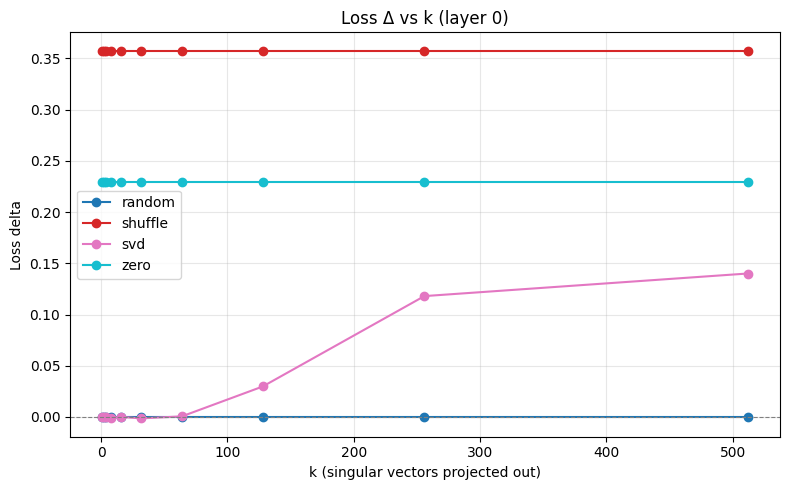

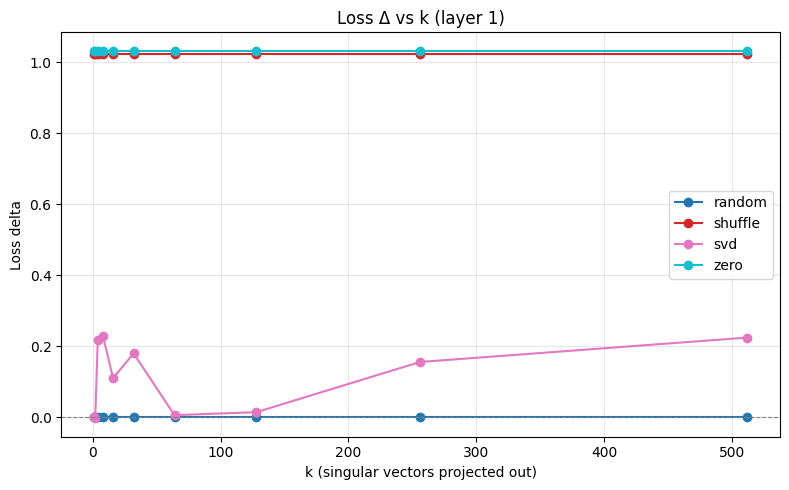

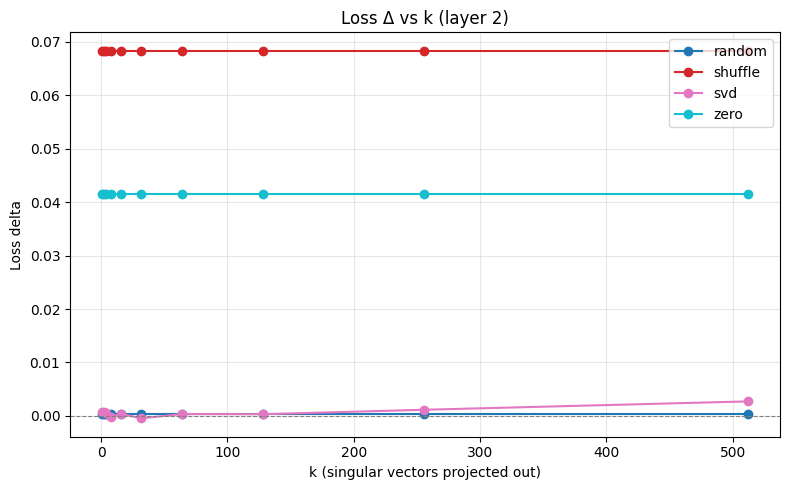

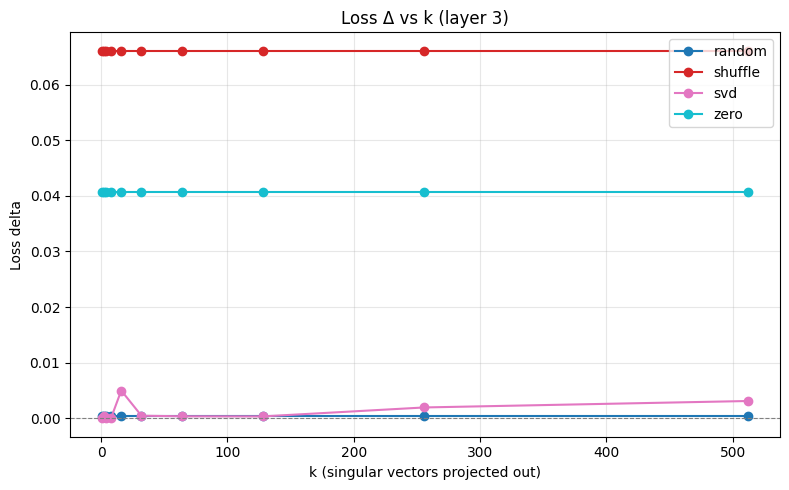

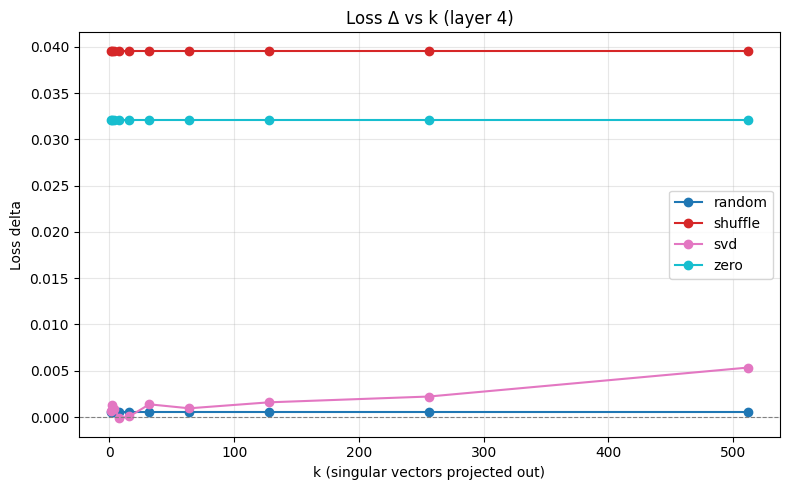

In [14]:
for layer in layer_results:
    fig2 = plot_delta_vs_k(
        layer_results[layer],
        title=f"Loss Δ vs k (layer {layer})",
    )
    fig2.show()